# Hospital Bed Occupancy Missing-Data Repair
**Project:** Mtech-DS26004  
**Student:** Ahmed Masood  
**Mode:** Executable analytical report  

This notebook evaluates mixed missingness mechanisms, benchmarks repair methods using hidden ground truth, engineers leakage-safe features, and reviews the critical-occupancy model.

## tl;dr
The generated results below quantify data quality, missingness, per-column imputation winners, model discrimination, and operating recommendations. Synthetic findings are evidence for this project dataset only; they are not clinical claims.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.data_loader import load_dataset
from src.data_validator import DataValidator
from src.missingness_analysis import missingness_summary, grouped_missingness, missingness_patterns, mechanism_evidence
from src.statistical_tests import run_statistical_tests
from src.feature_engineering import FEATURE_DOCUMENTATION
sns.set_theme(style='whitegrid'); pd.set_option('display.max_columns', 60)
print(f'Project root: {ROOT}')

Project root: C:\Users\CITY COM\Documents\Codex\2026-07-20\create-a-complete-advanced-original-professional\Mtech-DS26004_Hospital_Bed_Occupancy


## Context & Methods
### Key Assumptions
- The CSV is synthetic and contains no patient-level identities.
- The >=90% critical threshold is a project convention, not a universal clinical rule.
- Repeated artificial masking estimates recoverability for observed values; it cannot prove MNAR recovery.
- Time features use past-only lags/rolling values.

### Evaluation design
Known values are hidden with deterministic seeds. MAE, RMSE, bias, distribution distortion, correlation preservation, and runtime are normalized within each column. The weighted score penalizes RMSE (34%), MAE (18%), absolute bias (14%), KS difference (12%), variance distortion (8%), runtime (6%), and correlation loss (8%).

## Data
### 1. Load and inspect

In [2]:
raw = load_dataset(ROOT / 'data/raw/hospital_bed_occupancy_raw.csv')
clean = load_dataset(ROOT / 'data/processed/hospital_bed_occupancy_clean.csv')
repaired = load_dataset(ROOT / 'data/processed/hospital_bed_occupancy_repaired.csv')
features = load_dataset(ROOT / 'data/processed/hospital_bed_occupancy_features.csv')
print({'raw_shape': raw.shape, 'clean_shape': clean.shape, 'repaired_shape': repaired.shape, 'feature_shape': features.shape})
raw.head(3)

{'raw_shape': (5400, 31), 'clean_shape': (5400, 31), 'repaired_shape': (5400, 31), 'feature_shape': (5400, 53)}


,record_id,date,hospital_name,department,hospital_type,city,ward,weekend_flag,holiday_flag,season,disease_outbreak_flag,total_beds,occupied_beds,reserved_beds,available_beds,emergency_beds,ICU_beds,ICU_occupied,ventilators_available,daily_admissions,daily_discharge,emergency_cases,staff_on_duty,nurses_on_duty,doctors_on_duty,average_length_of_stay,patient_turnover_rate,occupancy_rate,mortality_rate,infection_rate,temperature
0,HBO-000001,2024-01-01,Apex Medical Center,Emergency,Teaching,Karachi,ER,0,1,Winter,0,56,45,2,9,17,7,6.0,1.0,NaN,15.0,NaN,23.0,NaN,NaN,NaN,26.79,80.36,4.00,1.88,NaN
1,HBO-000002,2024-01-01,Apex Medical Center,ICU,Teaching,Karachi,ICU,0,1,Winter,0,19,16,1,2,1,14,12.0,3.0,5.0,7.0,NaN,13.0,8.0,NaN,3.88,NaN,84.21,5.25,12.65,20.2
2,HBO-000003,2024-01-01,Apex Medical Center,Cardiology,Teaching,Karachi,Cardiac,0,1,Winter,0,60,36,1,23,4,7,4.0,NaN,6.0,10.0,10.0,15.0,11.0,2.0,1.07,16.67,60.00,2.14,9.03,20.3


### 2. Validate structural and operational constraints
The validator checks identifiers, dates, duplicates, non-negativity, categorical domains, bed/ICU limits, staffing consistency, bed balances, occupancy bounds, and extreme IQR outliers.

In [3]:
quality = DataValidator().validate(clean)
pd.DataFrame(quality['issues']) if quality['issues'] else pd.DataFrame([{'status':'All rules passed'}])

,rule,severity,count,description
0,extreme_outliers,warning,2816,Values beyond 3 IQRs


In [4]:
pd.Series({k:v for k,v in quality.items() if k != 'issues'}, name='value').to_frame()

,value
rows,5400.000
columns,31.000
missing_cells,7603.000
missing_percentage,4.542
duplicate_rows,0.000
quality_score,94.620


### 3. Missing-data analysis

In [5]:
missing = missingness_summary(clean)
missing.style.format({'missing_percentage': '{:.2f}%'})

,missing_count,missing_percentage
temperature,727,13.46%
patient_turnover_rate,707,13.09%
daily_admissions,703,13.02%
occupancy_rate,662,12.26%
doctors_on_duty,634,11.74%
infection_rate,614,11.37%
nurses_on_duty,614,11.37%
emergency_cases,560,10.37%
mortality_rate,516,9.56%
daily_discharge,504,9.33%


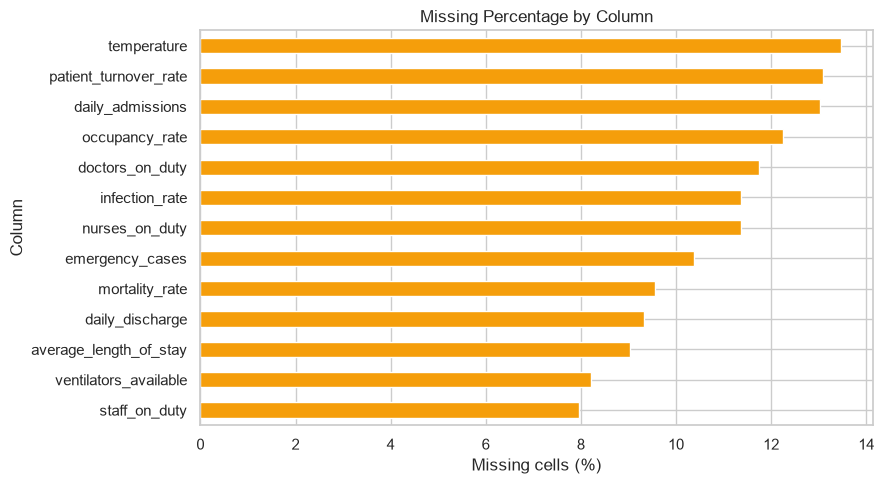

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
missing.sort_values('missing_percentage').missing_percentage.plot.barh(ax=ax, color='#F59E0B')
ax.set(title='Missing Percentage by Column', xlabel='Missing cells (%)', ylabel='Column')
plt.tight_layout(); plt.show()

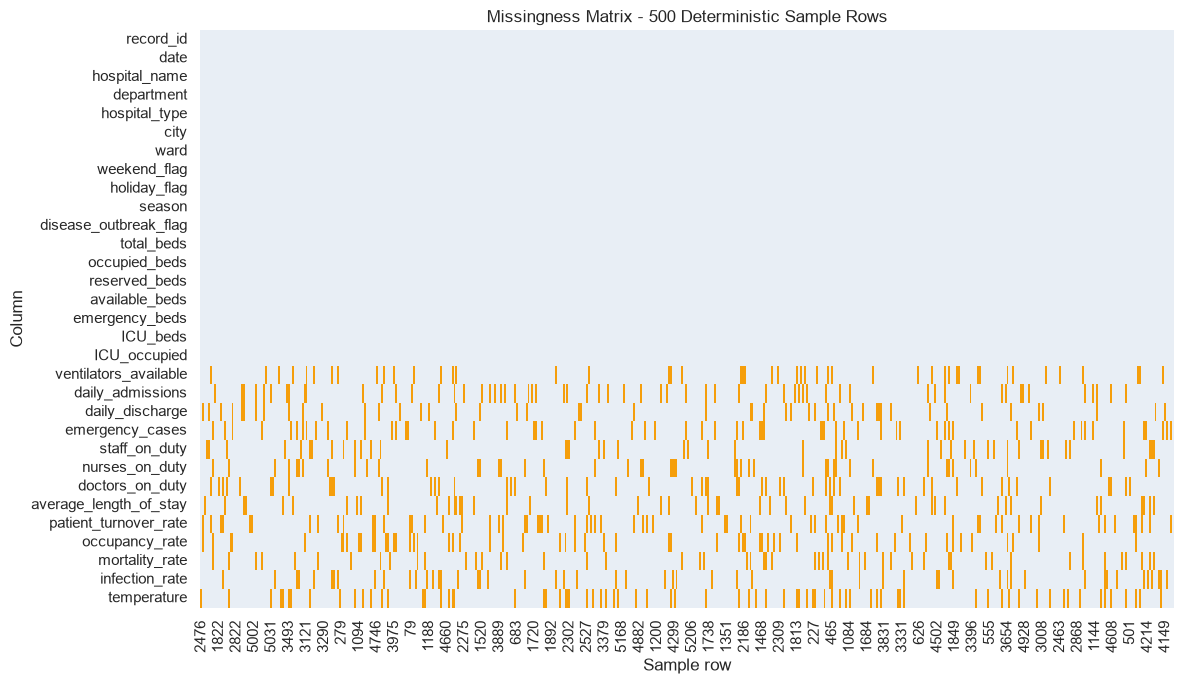

In [7]:
sample_mask = clean.sample(min(500, len(clean)), random_state=42).isna().T
fig, ax = plt.subplots(figsize=(12, 7)); sns.heatmap(sample_mask, cmap=['#E8EEF5','#F59E0B'], cbar=False, ax=ax)
ax.set(title='Missingness Matrix - 500 Deterministic Sample Rows', xlabel='Sample row', ylabel='Column'); plt.tight_layout(); plt.show()

### 4. Missingness by department, hospital, weekday, date, and season

In [8]:
display(grouped_missingness(clean, 'department').round(1))
display(grouped_missingness(clean, 'hospital_name').round(1))
display(grouped_missingness(clean, 'weekend_flag').round(1))
display(grouped_missingness(clean, 'season').round(1))

,record_id,date,hospital_name,hospital_type,city,ward,weekend_flag,holiday_flag,season,disease_outbreak_flag,total_beds,occupied_beds,reserved_beds,available_beds,emergency_beds,ICU_beds,ICU_occupied,ventilators_available,daily_admissions,daily_discharge,emergency_cases,staff_on_duty,nurses_on_duty,doctors_on_duty,average_length_of_stay,patient_turnover_rate,occupancy_rate,mortality_rate,infection_rate,temperature
department,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cardiology,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.3,13.6,7.2,8.3,7.3,11.9,12.4,7.3,12.6,11.9,9.0,11.2,13.8
Emergency,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,12.8,7.9,18.8,8.4,11.8,10.6,9.3,13.2,12.3,9.3,8.7,12.4
ICU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.2,13.1,5.9,8.6,8.1,11.1,14.0,9.9,14.3,12.6,11.9,13.2,13.4
Medicine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,12.2,9.2,10.1,8.0,12.9,11.0,7.9,13.4,12.3,9.1,10.7,13.2
Pediatrics,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.2,13.9,7.0,8.3,6.3,11.1,10.6,8.7,12.7,12.0,7.8,12.0,14.2
Surgery,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.6,12.6,18.8,8.1,9.6,9.4,11.9,11.1,12.3,12.4,10.2,12.4,13.7


,record_id,date,department,hospital_type,city,ward,weekend_flag,holiday_flag,season,disease_outbreak_flag,total_beds,occupied_beds,reserved_beds,available_beds,emergency_beds,ICU_beds,ICU_occupied,ventilators_available,daily_admissions,daily_discharge,emergency_cases,staff_on_duty,nurses_on_duty,doctors_on_duty,average_length_of_stay,patient_turnover_rate,occupancy_rate,mortality_rate,infection_rate,temperature
hospital_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Apex Medical Center,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.2,11.2,10.0,10.0,9.0,11.2,11.8,9.6,13.5,14.0,10.0,13.1,13.5
City General Hospital,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.3,14.5,9.2,10.6,8.5,10.8,11.5,8.7,11.2,11.0,9.4,10.9,14.3
North Star Clinic,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.6,15.2,10.1,9.8,7.2,11.1,12.1,9.2,13.4,10.3,9.8,10.9,12.8
Riverbend Hospital,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.4,13.6,8.5,9.6,7.0,13.1,11.9,9.8,13.7,12.9,9.8,10.2,14.7
Unity Health Institute,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.5,10.6,8.9,11.9,8.1,10.6,11.4,7.9,13.6,13.1,8.8,11.8,12.0


,record_id,date,hospital_name,department,hospital_type,city,ward,holiday_flag,season,disease_outbreak_flag,total_beds,occupied_beds,reserved_beds,available_beds,emergency_beds,ICU_beds,ICU_occupied,ventilators_available,daily_admissions,daily_discharge,emergency_cases,staff_on_duty,nurses_on_duty,doctors_on_duty,average_length_of_stay,patient_turnover_rate,occupancy_rate,mortality_rate,infection_rate,temperature
weekend_flag,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.2,13.1,9.2,10.1,7.4,7.7,11.7,8.7,12.8,11.3,9.7,7.6,13.7
1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.4,12.7,9.7,11.0,9.5,21.0,11.8,10.0,13.9,14.7,9.1,21.3,12.9


,record_id,date,hospital_name,department,hospital_type,city,ward,weekend_flag,holiday_flag,disease_outbreak_flag,total_beds,occupied_beds,reserved_beds,available_beds,emergency_beds,ICU_beds,ICU_occupied,ventilators_available,daily_admissions,daily_discharge,emergency_cases,staff_on_duty,nurses_on_duty,doctors_on_duty,average_length_of_stay,patient_turnover_rate,occupancy_rate,mortality_rate,infection_rate,temperature
season,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Spring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.2,12.9,9.1,10.4,7.5,11.4,11.8,9.2,13.9,10.6,9.5,12.2,13.2
Summer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.9,12.1,9.4,8.6,6.4,11.9,11.0,10.7,11.0,14.6,8.5,10.6,14.4
Winter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.9,13.7,9.7,11.1,9.4,11.1,11.9,8.1,12.8,13.7,10.2,10.4,13.4


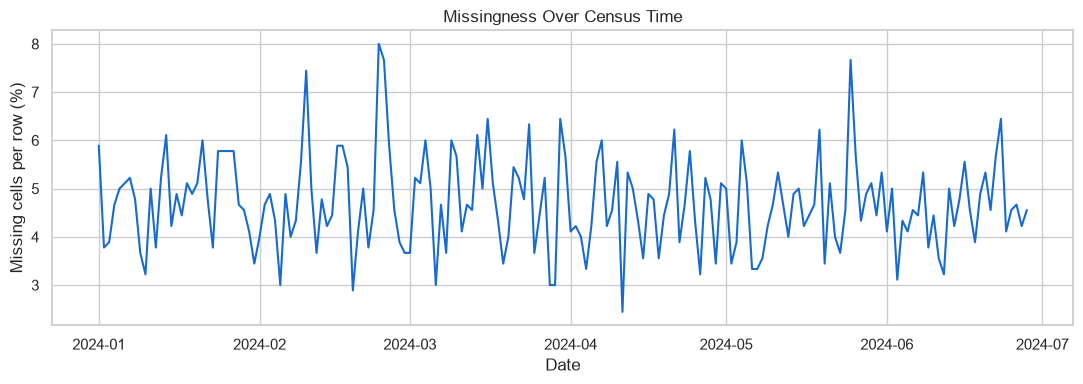

In [9]:
date_missing = clean.set_index('date').isna().mean(axis=1).groupby(level=0).mean() * 100
fig, ax = plt.subplots(figsize=(11, 4)); ax.plot(date_missing.index, date_missing, color='#176BCE'); ax.set(title='Missingness Over Census Time', xlabel='Date', ylabel='Missing cells per row (%)'); plt.tight_layout(); plt.show()

### 5. Missingness correlation and patterns

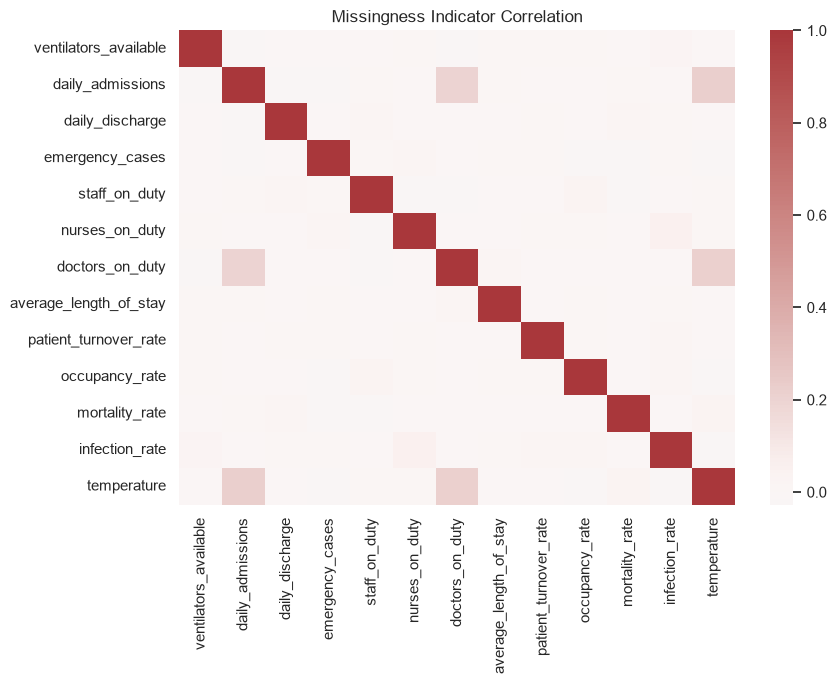

,pattern,rows
0,Complete,1294
1,patient_turnover_rate,201
2,occupancy_rate,190
3,infection_rate,149
4,temperature,148
5,emergency_cases,148
6,mortality_rate,144
7,doctors_on_duty,142
8,daily_admissions,142
9,nurses_on_duty,141


In [10]:
indicator_corr = clean.loc[:, clean.isna().any()].isna().astype(int).corr()
fig, ax = plt.subplots(figsize=(9, 7)); sns.heatmap(indicator_corr, cmap='vlag', center=0, ax=ax); ax.set(title='Missingness Indicator Correlation'); plt.tight_layout(); plt.show()
missingness_patterns(clean)

In [11]:
mechanisms = mechanism_evidence(clean)
pd.DataFrame([{'column': c, **v} for c,v in mechanisms['columns'].items()])

,column,likely_mechanism,associations
0,ventilators_available,MAR-like,"[(department, 3.9400757209714683e-44)]"
1,daily_admissions,MAR-like,"[(hospital_name, 0.0031029675980073293)]"
2,daily_discharge,MAR-like,"[(department, 2.7825772929122297e-24)]"
3,emergency_cases,MAR-like,"[(department, 8.811388112554731e-17)]"
4,staff_on_duty,MAR-like,"[(weekend_flag, 0.009668268972015254), (holida..."
5,nurses_on_duty,MAR-like,"[(weekend_flag, 3.5325612871975595e-43), (holi..."
6,doctors_on_duty,MAR-like,"[(holiday_flag, 0.0009145396253837352)]"
7,average_length_of_stay,MNAR-designed,[]
8,patient_turnover_rate,MCAR-like,[]
9,occupancy_rate,MAR-like,"[(hospital_name, 0.0470603944469863), (weekend..."


**Interpretation.** Significant associations with observed department, hospital, weekend, holiday, or season variables are MAR-like evidence. Mortality and length of stay are MNAR-designed in the generator. Because MNAR depends on unobserved values, imputation cannot guarantee unbiased recovery and manual review remains necessary.

## Results
### 6. Exploratory data analysis

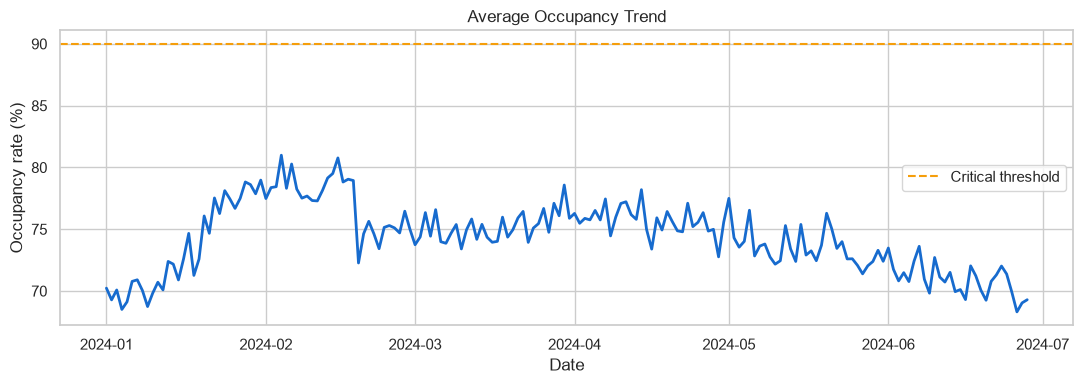

In [12]:
trend = repaired.groupby('date', as_index=False).occupancy_rate.mean()
fig, ax = plt.subplots(figsize=(11, 4)); ax.plot(trend.date, trend.occupancy_rate, color='#176BCE', lw=2); ax.axhline(90, ls='--', color='#F59E0B', label='Critical threshold'); ax.set(title='Average Occupancy Trend', xlabel='Date', ylabel='Occupancy rate (%)'); ax.legend(); plt.tight_layout(); plt.show()

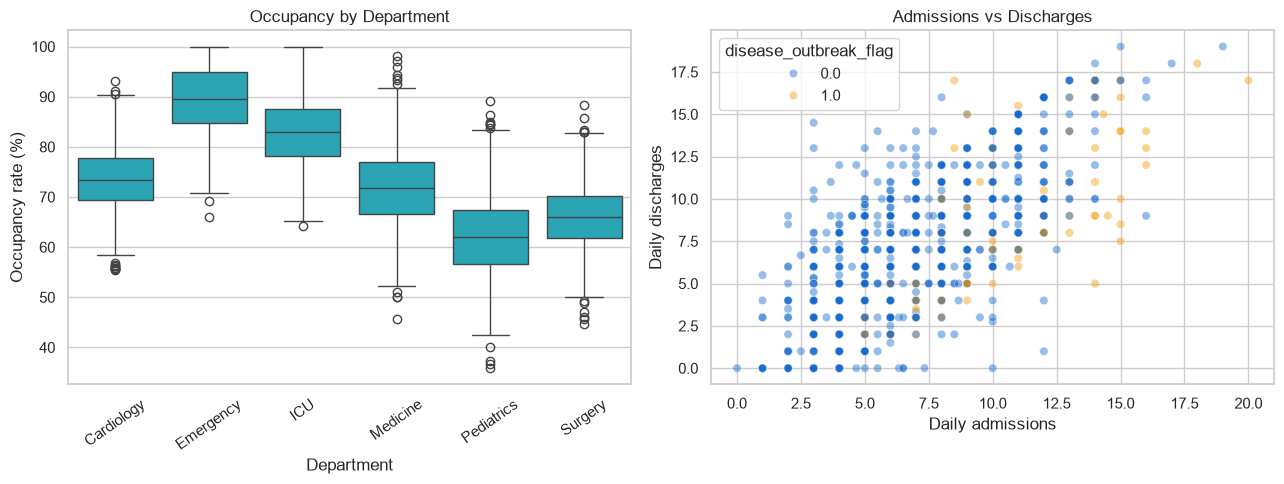

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=repaired, x='department', y='occupancy_rate', color='#15B7C9', ax=axes[0]); axes[0].tick_params(axis='x', rotation=35); axes[0].set(title='Occupancy by Department', xlabel='Department', ylabel='Occupancy rate (%)')
sns.scatterplot(data=repaired.sample(1200, random_state=42), x='daily_admissions', y='daily_discharge', hue='disease_outbreak_flag', palette=['#176BCE','#F59E0B'], alpha=.45, ax=axes[1]); axes[1].set(title='Admissions vs Discharges', xlabel='Daily admissions', ylabel='Daily discharges'); plt.tight_layout(); plt.show()

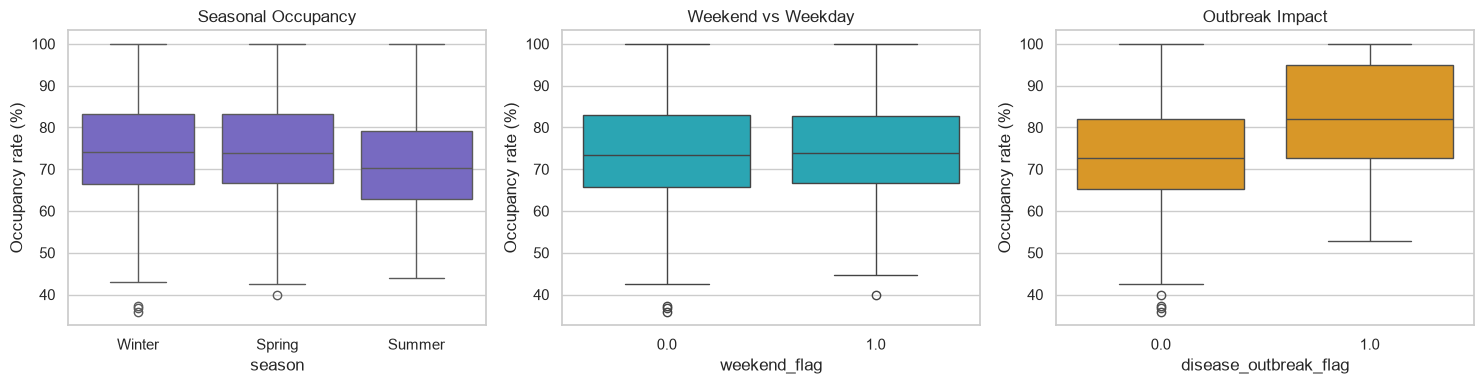

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=repaired, x='season', y='occupancy_rate', color='#6D5BD0', ax=axes[0]); axes[0].set(title='Seasonal Occupancy')
sns.boxplot(data=repaired, x='weekend_flag', y='occupancy_rate', color='#15B7C9', ax=axes[1]); axes[1].set(title='Weekend vs Weekday')
sns.boxplot(data=repaired, x='disease_outbreak_flag', y='occupancy_rate', color='#F59E0B', ax=axes[2]); axes[2].set(title='Outbreak Impact')
for ax in axes: ax.set_ylabel('Occupancy rate (%)')
plt.tight_layout(); plt.show()

### 7. Statistical tests
Each test includes its purpose. Parametric and robust non-parametric counterparts are both reported where distributional assumptions may fail.

In [15]:
tests = run_statistical_tests(repaired)
pd.json_normalize(tests, sep=' → ').T.rename(columns={0:'result'}).head(35)

,result
confidence_interval_95,"[74.0190764878432, 74.64305499363829]"
pearson_occupied_admissions,0.170121
spearman_staff_occupancy,0.164433
mcar_note,Little's test is not run because mixed-type hi...
descriptive → mean,74.331066
descriptive → median,73.47
descriptive → mode,66.67
descriptive → variance,136.767246
descriptive → standard_deviation,11.694753
descriptive → skewness,0.08216


### 8. Imputation benchmark and best method per column

In [16]:
benchmark = pd.read_csv(ROOT / 'outputs/experiments/imputation_comparison.csv')
cols = ['column','method','mae_mean','rmse_mean','bias_mean','ks_statistic_mean','runtime_seconds_mean','final_score','rank']
benchmark[cols].sort_values(['column','rank']).head(30).style.background_gradient(subset=['final_score'], cmap='Blues')

,column,method,mae_mean,rmse_mean,bias_mean,ks_statistic_mean,runtime_seconds_mean,final_score,rank
6,ICU_beds,knn,0.325507,0.621470,0.017874,0.110185,2.964702,79.313471,1.000000
5,ICU_beds,iterative,0.676996,0.936301,0.035157,0.162037,3.391927,72.703995,2.000000
12,ICU_beds,rolling_median,1.186111,1.748518,0.066667,0.102778,0.034545,67.937603,3.000000
7,ICU_beds,linear_interpolation,1.345370,1.918480,-0.003241,0.106481,0.027754,65.443752,4.000000
14,ICU_beds,time_interpolation,1.345370,1.918480,-0.003241,0.106481,0.069241,65.370280,5.000000
0,ICU_beds,backward_fill,1.493519,2.204451,0.006481,0.026852,0.021596,63.487122,6.000000
2,ICU_beds,forward_fill,1.550000,2.296216,-0.012963,0.024074,0.022350,62.461409,7.000000
1,ICU_beds,department_mean,1.282162,1.822531,-0.005761,0.431481,0.017601,60.821913,8.000000
11,ICU_beds,polynomial_interpolation,1.633100,2.300866,-0.045888,0.151852,0.041239,59.636328,9.000000
3,ICU_beds,hospital_median,2.450000,4.497709,-1.631481,0.232407,0.018734,34.195209,10.000000


In [17]:
winners = benchmark[benchmark['rank'].eq(1)].sort_values('column')
winners[['column','method','mae_mean','rmse_mean','bias_mean','distribution_similarity_mean','final_score']]

,column,method,mae_mean,rmse_mean,bias_mean,distribution_similarity_mean,final_score
6,ICU_beds,knn,3.255074e-01,6.214703e-01,1.787378e-02,0.889815,79.313471
20,ICU_occupied,iterative,6.304103e-01,8.809354e-01,-4.689412e-02,0.829630,76.848012
35,available_beds,iterative,9.417744e-13,1.219028e-12,-1.286096e-14,0.947222,80.194182
46,average_length_of_stay,department_mean,1.804622e+00,2.361098e+00,-1.602691e-02,0.505092,66.469679
65,daily_admissions,iterative,1.572028e+00,1.896283e+00,1.491141e-02,0.874200,74.831498
80,daily_discharge,iterative,1.448858e+00,1.861569e+00,4.406089e-02,0.905930,80.969132
102,disease_outbreak_flag,rolling_median,3.703704e-03,4.709765e-02,-2.777778e-03,0.994444,85.782931
110,doctors_on_duty,iterative,5.369191e-01,6.701252e-01,4.120445e-03,0.775210,76.068739
132,emergency_beds,rolling_median,6.643519e-01,1.181353e+00,-5.092593e-03,0.912037,85.346243
147,emergency_cases,rolling_median,2.683884e+00,3.445190e+00,2.376033e-02,0.861570,66.961987


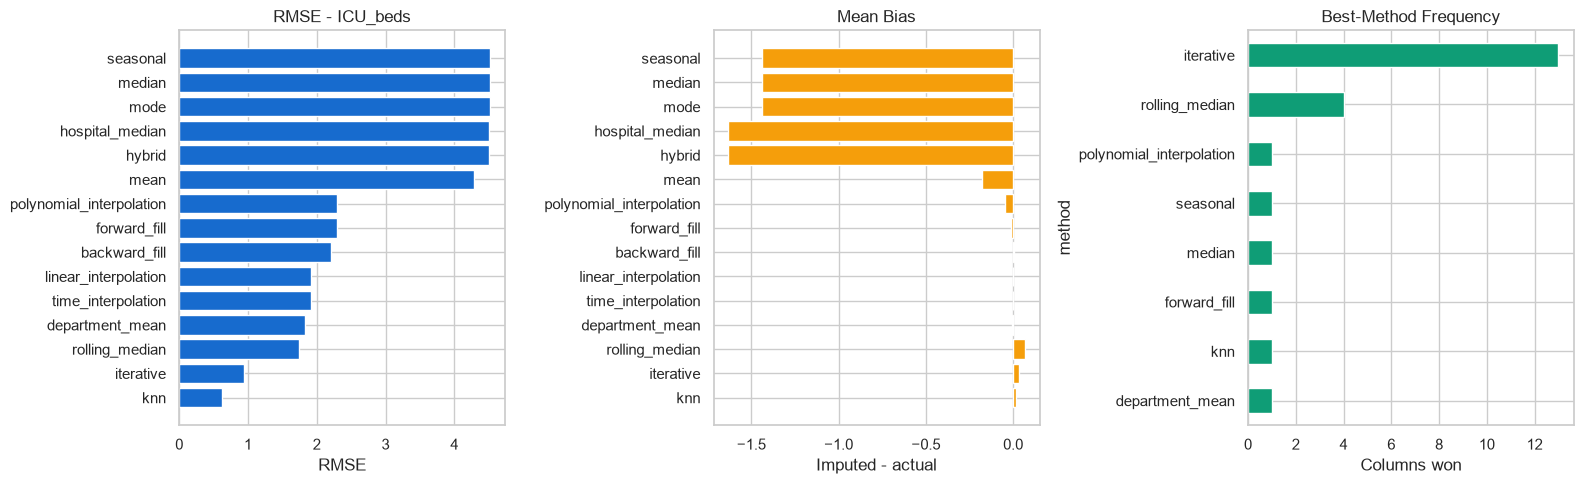

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
example = benchmark[benchmark.column.eq(benchmark.column.iloc[0])].sort_values('rmse_mean')
axes[0].barh(example.method, example.rmse_mean, color='#176BCE'); axes[0].set(title=f'RMSE - {example.column.iloc[0]}', xlabel='RMSE')
axes[1].barh(example.method, example.bias_mean, color='#F59E0B'); axes[1].set(title='Mean Bias', xlabel='Imputed - actual')
winners.method.value_counts().sort_values().plot.barh(ax=axes[2], color='#0F9D76'); axes[2].set(title='Best-Method Frequency', xlabel='Columns won')
plt.tight_layout(); plt.show()

### 9. Distribution before and after repair

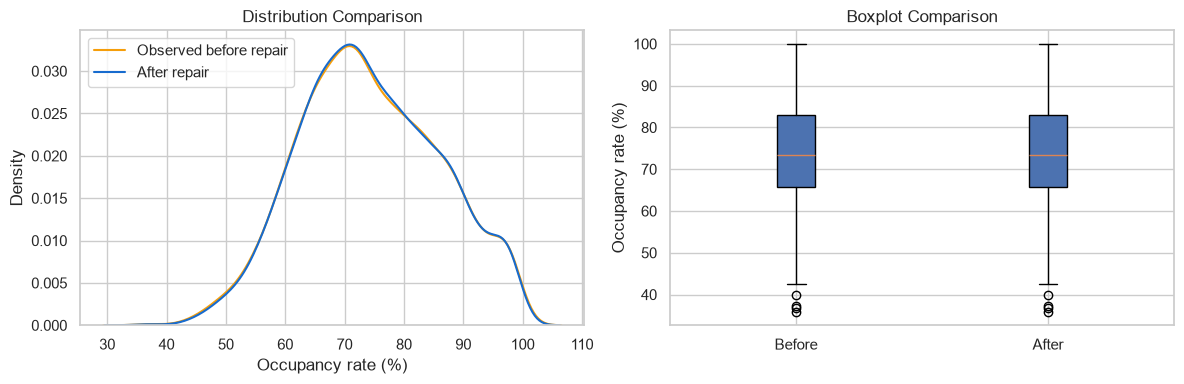

In [19]:
column='occupancy_rate'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(clean[column].dropna(), label='Observed before repair', color='#F59E0B', ax=axes[0]); sns.kdeplot(repaired[column], label='After repair', color='#176BCE', ax=axes[0]); axes[0].set(title='Distribution Comparison', xlabel='Occupancy rate (%)'); axes[0].legend()
axes[1].boxplot([clean[column].dropna(), repaired[column]], tick_labels=['Before','After'], patch_artist=True); axes[1].set(title='Boxplot Comparison', ylabel='Occupancy rate (%)'); plt.tight_layout(); plt.show()

### 10. Feature engineering and leakage audit

In [20]:
pd.DataFrame(FEATURE_DOCUMENTATION.items(), columns=['feature family','definition'])

,feature family,definition
0,occupancy_rate,occupied_beds / total_beds x 100
1,ICU_occupancy_rate,ICU_occupied / ICU_beds x 100
2,bed_utilization_ratio,(occupied + reserved) / total beds
3,admission_discharge_ratio,"admissions / max(discharges, 1)"
4,staff_to_patient_ratio,"staff / max(occupied beds, 1)"
5,nurse_to_patient_ratio,"nurses / max(occupied beds, 1)"
6,doctor_to_patient_ratio,"doctors / max(occupied beds, 1)"
7,emergency_pressure_index,"emergency cases / max(emergency beds, 1)"
8,bed_shortage_flag,available beds <= 5
9,high_occupancy_flag,occupancy >= 80%


In [21]:
leakage_exclusions = json.load(open(ROOT / 'config/model_config.json', encoding='utf-8'))['excluded_leakage_features']
print('Excluded from predictors:', leakage_exclusions)
features[['occupancy_lag_1','occupancy_lag_7','seven_day_rolling_occupancy','critical_occupancy_flag']].head(10)

Excluded from predictors: ['record_id', 'date', 'occupancy_rate', 'occupied_beds', 'available_beds', 'high_occupancy_flag', 'bed_shortage_flag', 'bed_utilization_ratio', 'staff_to_patient_ratio', 'nurse_to_patient_ratio', 'doctor_to_patient_ratio']


,occupancy_lag_1,occupancy_lag_7,seven_day_rolling_occupancy,critical_occupancy_flag
0,NaN,NaN,NaN,0
1,60.000000,NaN,60.000000,0
2,62.500000,NaN,61.250000,0
3,63.636364,NaN,62.045455,0
4,69.387755,NaN,63.881030,0
5,65.454545,NaN,64.195733,0
6,72.972973,NaN,65.658606,0
7,79.591837,60.000000,67.649068,0
8,66.037736,62.500000,68.511601,0
9,75.675676,63.636364,70.393841,0


### 11. Model comparison and evaluation

In [22]:
model_comparison = pd.read_csv(ROOT / 'outputs/experiments/model_comparison.csv')
model_comparison.sort_values('validation_business_score', ascending=False)

,model,validation_business_score,runtime_seconds,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,balanced_accuracy,matthews_correlation_coefficient,log_loss,brier_score
0,Logistic Regression,0.938915,0.219820,0.871296,0.462810,0.925620,0.864442,0.617080,0.958859,0.765586,0.895031,0.597631,0.251475,0.081390
1,Random Forest,0.928364,1.627254,0.879630,0.480349,0.909091,0.875912,0.628571,0.957273,0.765042,0.892502,0.605747,0.204796,0.066420
2,Decision Tree,0.834218,0.172543,0.863889,0.441441,0.809917,0.870699,0.571429,0.870668,0.601471,0.840308,0.531232,0.981955,0.098909
3,XGBoost,0.769731,0.795958,0.926852,0.684211,0.644628,0.962461,0.663830,0.957385,0.762079,0.803544,0.623180,0.161025,0.051456
4,Support Vector Machine,0.767618,2.234006,0.921296,0.650000,0.644628,0.956204,0.647303,0.952102,0.762490,0.800416,0.603016,0.163730,0.050046
5,Gradient Boosting,0.763655,5.398163,0.927778,0.693694,0.636364,0.964546,0.663793,0.954593,0.750366,0.800455,0.624149,0.165291,0.051277
6,K-Nearest Neighbors,0.753014,2.081502,0.924074,0.669565,0.636364,0.960375,0.652542,0.927990,0.723463,0.798370,0.610202,0.406499,0.052594


In [23]:
evaluation = json.load(open(ROOT / 'outputs/reports/model_evaluation.json', encoding='utf-8'))
pd.Series({k:v for k,v in evaluation['test_metrics'].items() if isinstance(v,(int,float))}, name='test value').to_frame()

,test value
accuracy,0.869444
precision,0.460000
recall_sensitivity,0.950413
specificity,0.859228
f1,0.619946
roc_auc,0.961737
pr_auc,0.761928
balanced_accuracy,0.904821
matthews_correlation_coefficient,0.605460
log_loss,0.261850


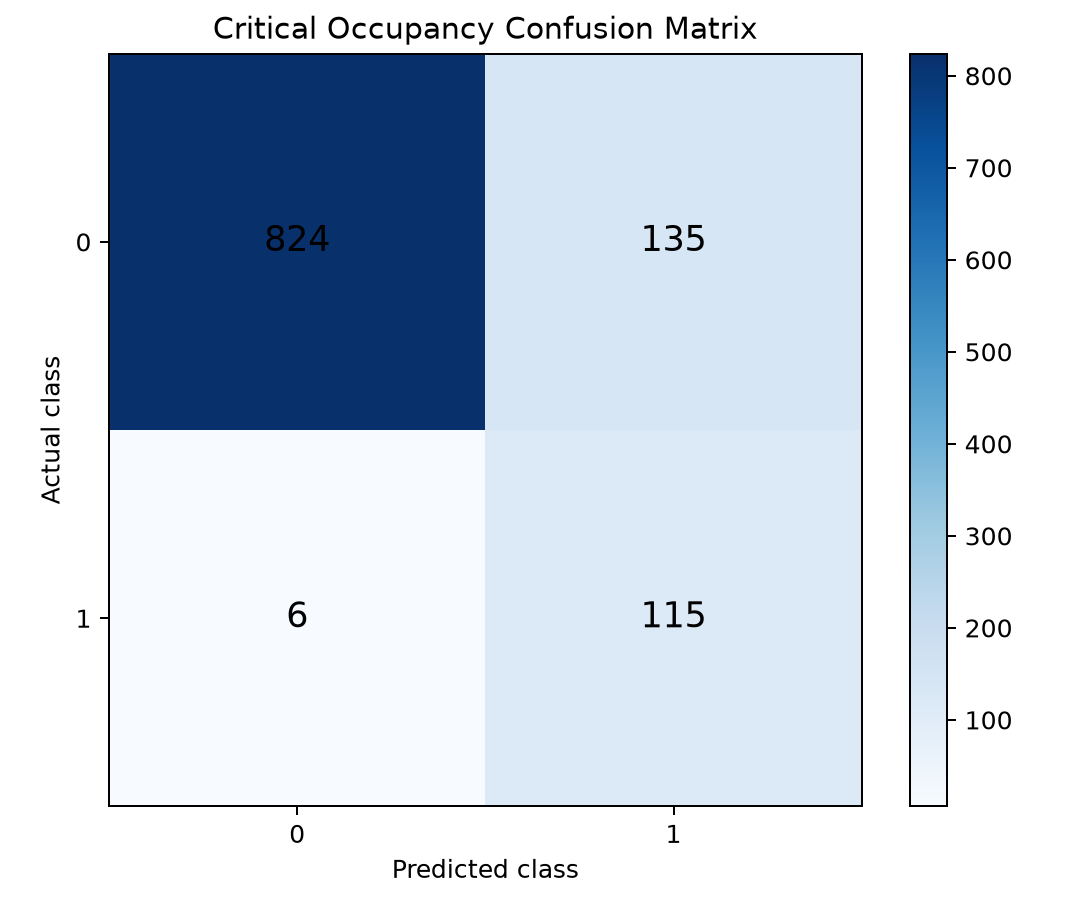

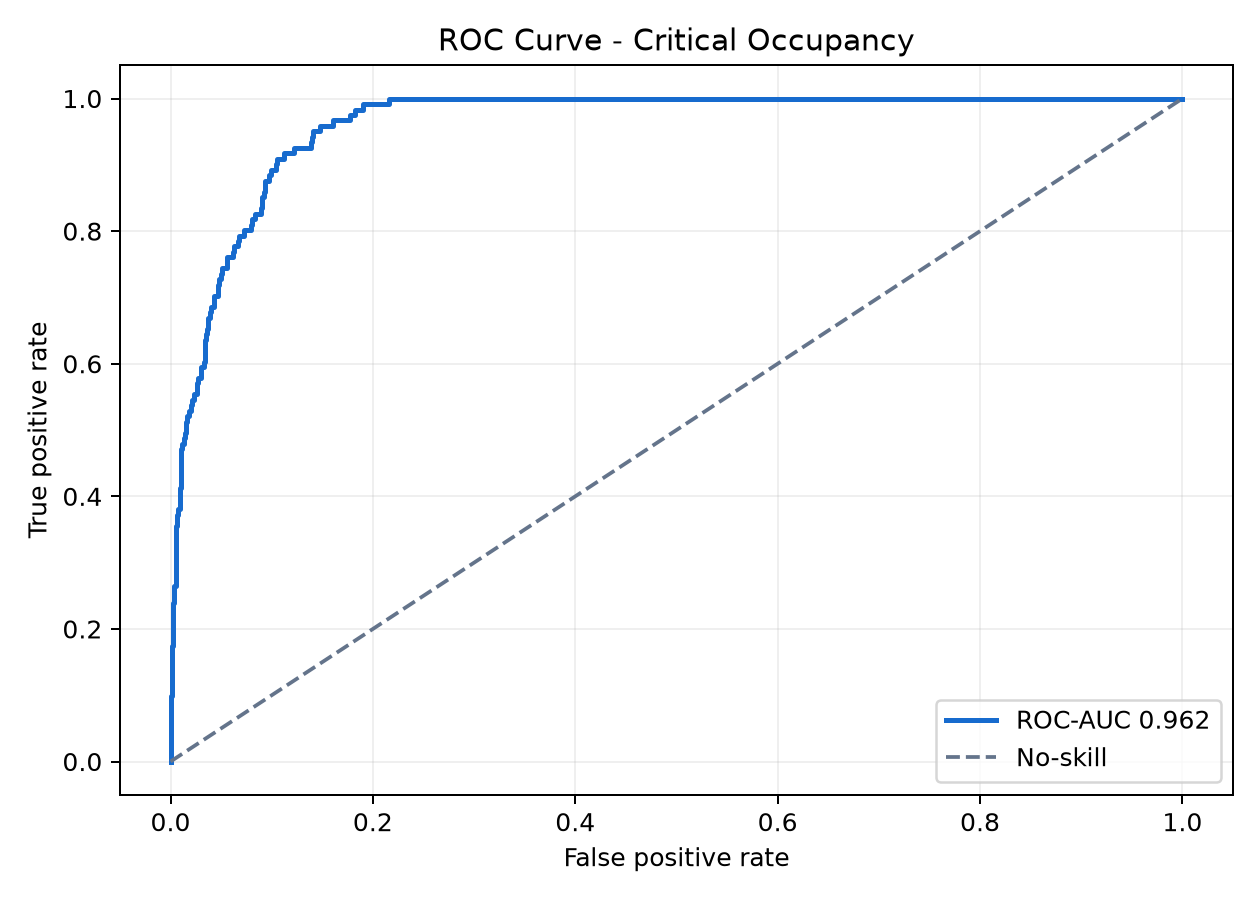

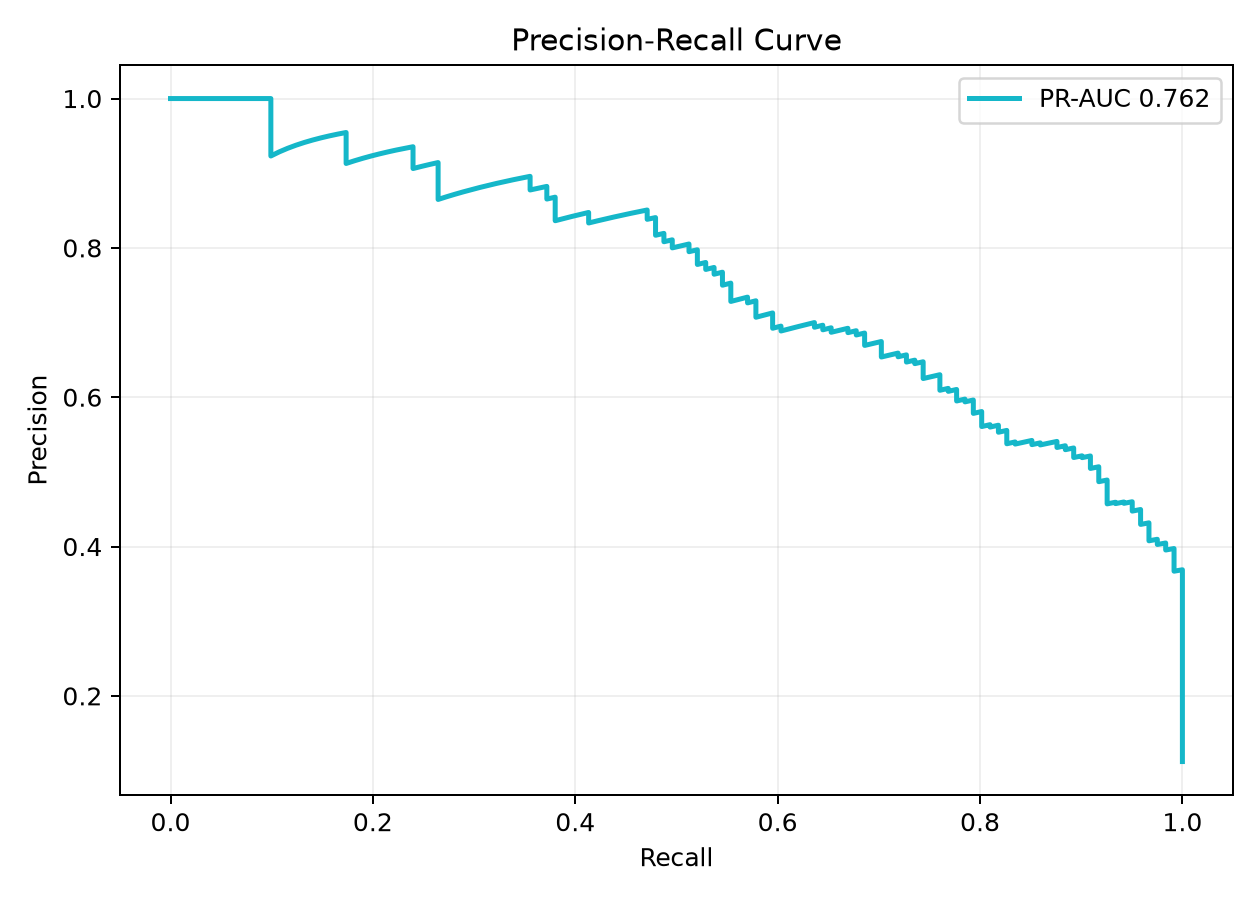

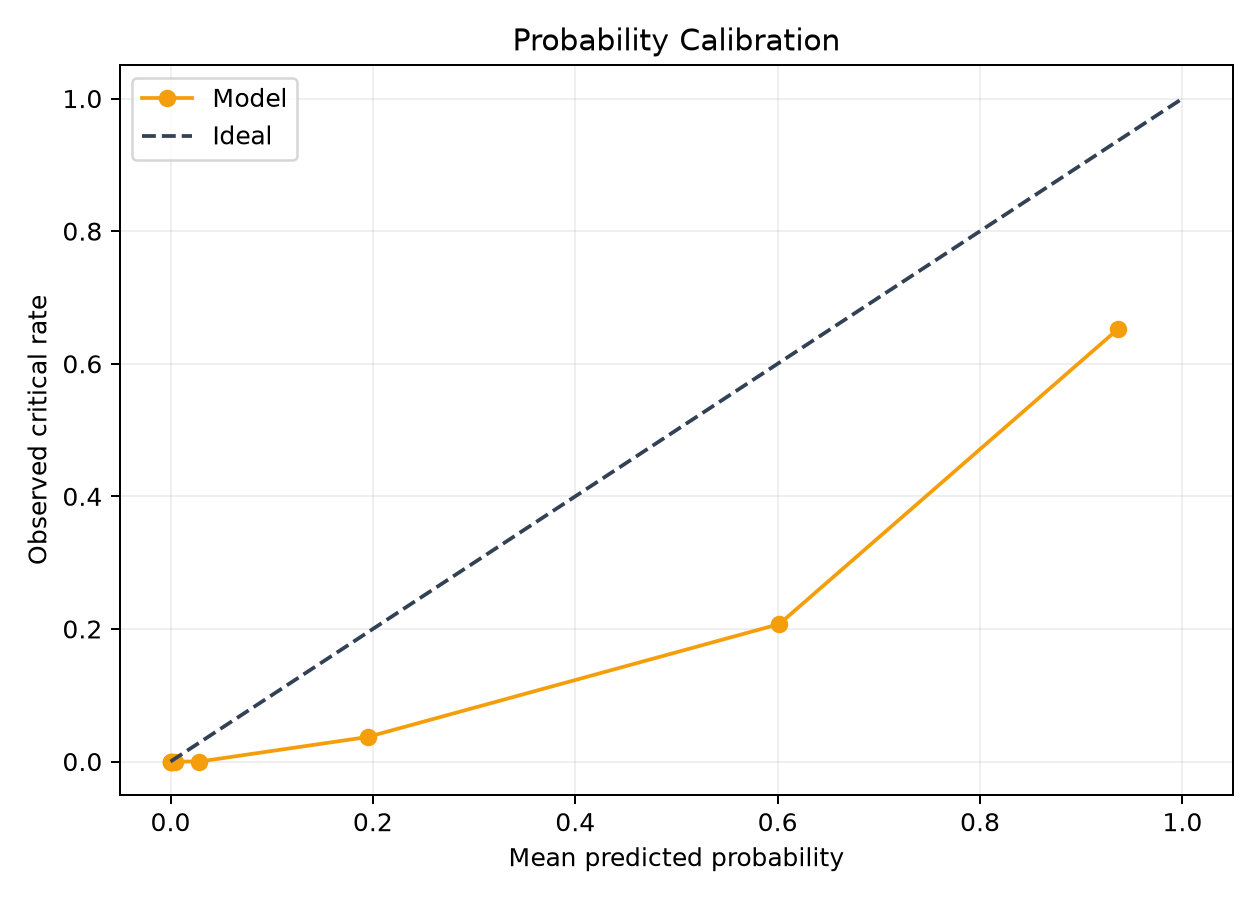

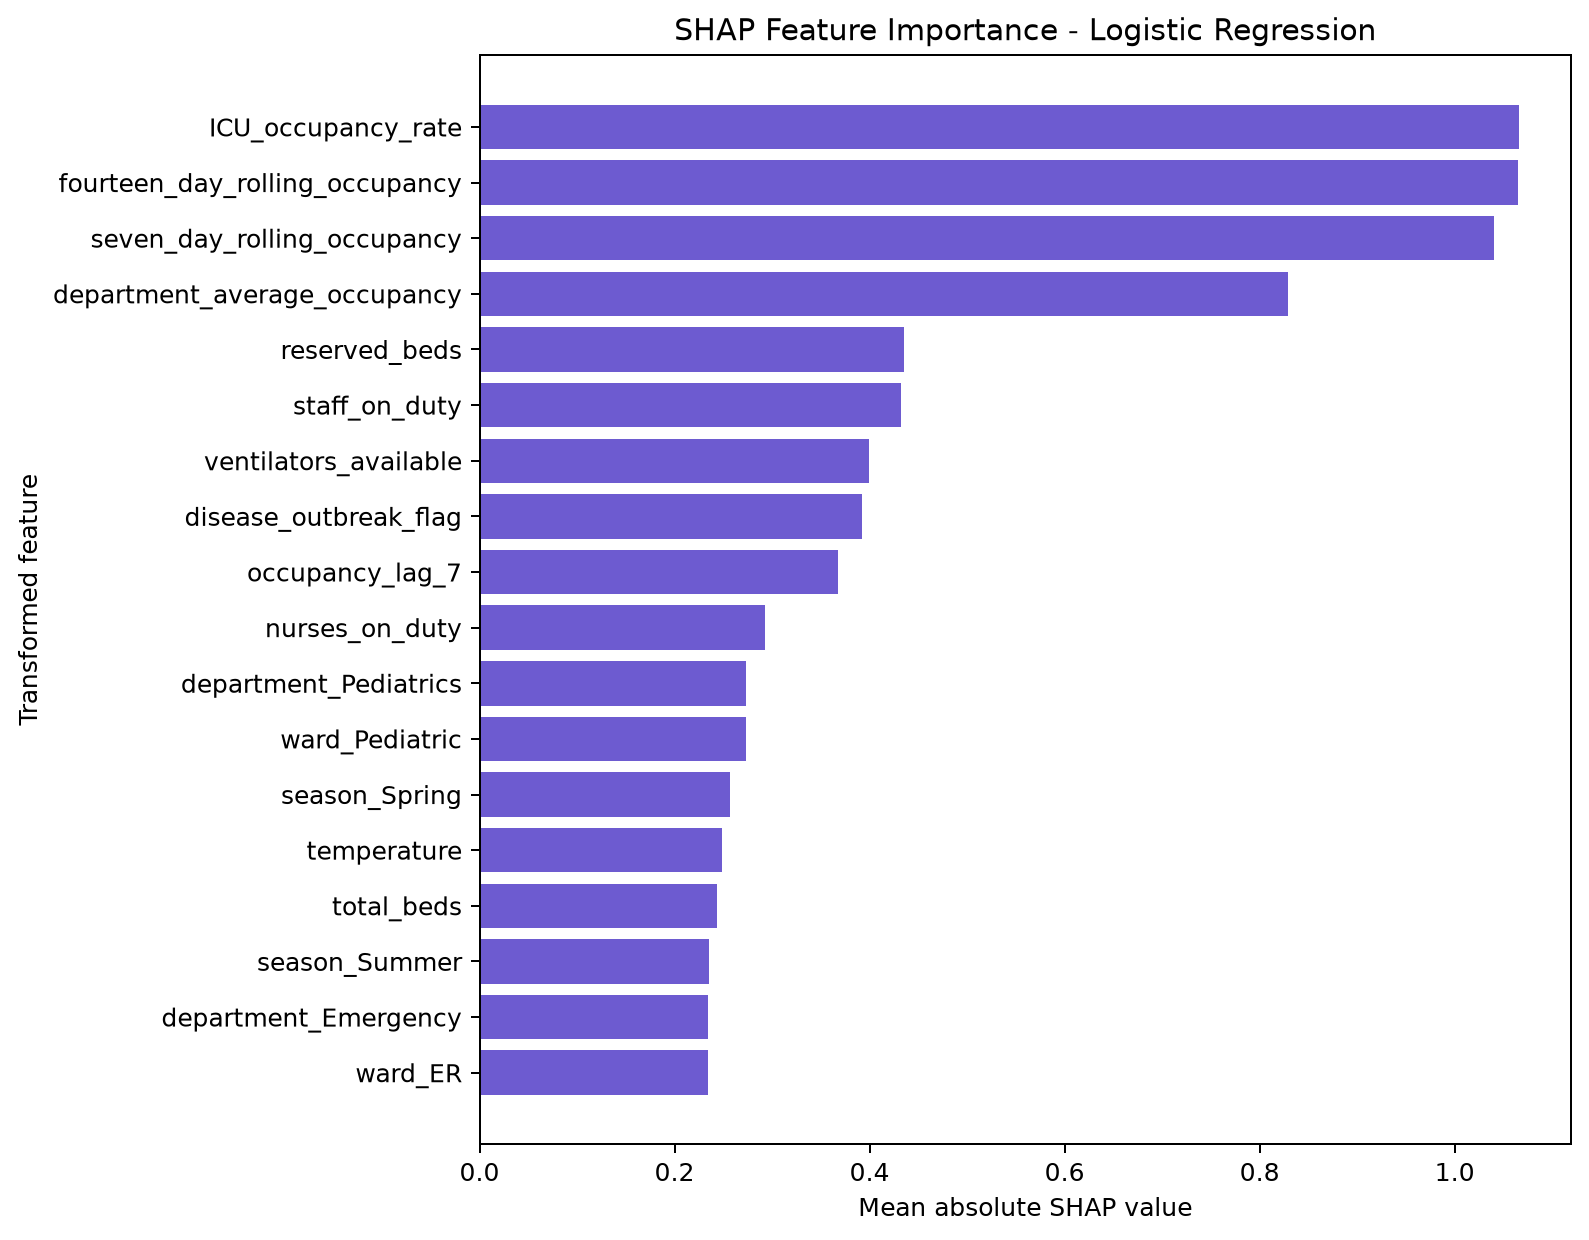

In [24]:
from IPython.display import Image, display
for name in ['confusion_matrix.png','roc_curve.png','precision_recall_curve.png','calibration_curve.png','shap_summary.png']:
    display(Image(filename=str(ROOT / 'outputs/charts' / name), width=620))

### 12. Findings and recommendations
**Verified findings** are generated from this dataset and saved benchmark/model outputs. **Assumptions** are design choices.

- Use the rank-1 repeated-mask method per numerical field; do not deploy one universal imputer.
- Department-aware strategies are candidates for staffing fields, while short temporal gaps favor interpolation when their validation score wins.
- Avoid mean imputation for strongly skewed length-of-stay and rare adverse-outcome fields.
- Long sequential gaps and MNAR-designed fields require manual review.
- Operational alerts at probability >=0.42 prioritize recall; capacity huddles should review ICU load, emergency pressure, admissions/discharges, and staffing.

## Takeaways
This project treats repair as a measured model-selection problem. The shipped benchmark preserves point accuracy, bias, distributions, correlation, and runtime; the classifier excludes direct threshold leakage; and the GUI exposes quality, repair, prediction, visualization, and reporting with human-review caveats.

### Honest limitations
Synthetic data cannot represent every hospital. MNAR recovery is intrinsically uncertain. Imputation cannot replace data collection. KNN/iterative methods are expensive at scale. Interpolation fails across long gaps. Model quality follows input quality, and critical thresholds require local validation.